In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("Food_Calorie_Prediction/dataset/food_calorie_dataset_400_rows.csv")

In [6]:
df.head()

,Food,Protein,Fat,Carbohydrates,Fiber,Sugar,Calories
0,Banana,1.3,0.3,23.6,2.9,11.1,92.4
1,Egg,10.7,11.4,1.1,0.0,1.2,150.4
2,Oats,15.5,7.3,64.0,11.6,1.0,359.7
3,Bread,8.5,3.5,57.8,2.7,5.2,287.3
4,Milk,2.7,0.8,4.9,0.0,5.4,38.1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Food           400 non-null    object 
 1   Protein        400 non-null    float64
 2   Fat            400 non-null    float64
 3   Carbohydrates  400 non-null    float64
 4   Fiber          400 non-null    float64
 5   Sugar          400 non-null    float64
 6   Calories       400 non-null    float64
dtypes: float64(6), object(1)
memory usage: 22.0+ KB


In [8]:
print(df)

       Food  Protein   Fat  Carbohydrates  Fiber  Sugar  Calories
0    Banana      1.3   0.3           23.6    2.9   11.1      92.4
1       Egg     10.7  11.4            1.1    0.0    1.2     150.4
2      Oats     15.5   7.3           64.0   11.6    1.0     359.7
3     Bread      8.5   3.5           57.8    2.7    5.2     287.3
4      Milk      2.7   0.8            4.9    0.0    5.4      38.1
..      ...      ...   ...            ...    ...    ...       ...
395    Milk      3.3   1.3            5.5    0.0    5.2      49.6
396     Dal      8.8   0.9           20.0    8.0    2.0     102.8
397    Milk      3.3   0.9            5.3    0.2    4.7      42.6
398     Egg     13.1  11.7            1.4    0.0    1.2     159.5
399   Apple      0.0   0.3           16.3    2.9    9.8      57.8

[400 rows x 7 columns]


In [9]:
df.isnull().sum()

Food             0
Protein          0
Fat              0
Carbohydrates    0
Fiber            0
Sugar            0
Calories         0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
print(df.shape)

(400, 7)


In [12]:
print(df.columns)

Index(['Food', 'Protein', 'Fat', 'Carbohydrates', 'Fiber', 'Sugar',
       'Calories'],
      dtype='object')


In [13]:
print(df.dtypes)

Food              object
Protein          float64
Fat              float64
Carbohydrates    float64
Fiber            float64
Sugar            float64
Calories         float64
dtype: object


In [14]:
print(df.describe())

          Protein         Fat  Carbohydrates       Fiber       Sugar  \
count  400.000000  400.000000     400.000000  400.000000  400.000000   
mean     9.557500    4.909000      21.240750    2.678500    3.892250   
std      7.917738    6.429426      20.676046    3.459814    4.006726   
min      0.000000    0.000000       0.000000    0.000000    0.000000   
25%      2.575000    0.400000       3.275000    0.000000    1.000000   
50%      8.800000    1.250000      18.550000    2.050000    2.000000   
75%     16.000000    7.200000      28.025000    2.800000    5.300000   
max     32.200000   23.700000      78.200000   11.800000   14.000000   

         Calories  
count  400.000000  
mean   161.950000  
std    101.442846  
min     33.500000  
25%     91.375000  
50%    131.900000  
75%    250.125000  
max    426.400000  


In [15]:
X = df[['Protein','Fat','Carbohydrates','Fiber','Sugar']]

y = df['Calories']

In [16]:
print(X.head())

   Protein   Fat  Carbohydrates  Fiber  Sugar
0      1.3   0.3           23.6    2.9   11.1
1     10.7  11.4            1.1    0.0    1.2
2     15.5   7.3           64.0   11.6    1.0
3      8.5   3.5           57.8    2.7    5.2
4      2.7   0.8            4.9    0.0    5.4


In [17]:
print(y.head())

0     92.4
1    150.4
2    359.7
3    287.3
4     38.1
Name: Calories, dtype: float64


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
print(X_train.shape)
print(X_test.shape)

(320, 5)
(80, 5)


In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred = model.predict(X_test)

In [22]:
print(y_pred[:10])

[347.78299478 364.4022053  106.50382049  51.10360171 127.99690377
 166.73299049 141.1742589   54.72386556 354.01946521 137.56491926]


In [23]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)

print("R2 Score:", score)

R2 Score: 0.999176882981201


In [24]:
import pandas as pd

results = pd.DataFrame({
    "Actual Calories": y_test.values,
    "Predicted Calories": y_pred
})

print(results.head(10))

   Actual Calories  Predicted Calories
0            351.6          347.782995
1            365.2          364.402205
2            106.7          106.503820
3             53.5           51.103602
4            124.2          127.996904
5            166.5          166.732990
6            139.0          141.174259
7             58.5           54.723866
8            356.7          354.019465
9            139.3          137.564919


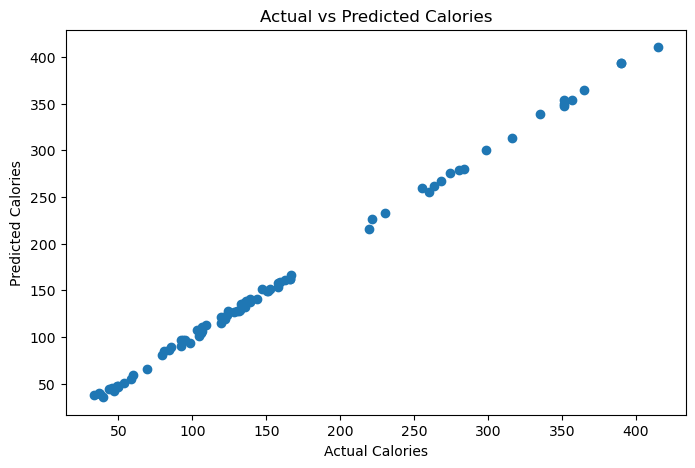

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")

plt.title("Actual vs Predicted Calories")

plt.show()

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred)**0.5


print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2.5166690414337802
RMSE: 2.858394822472534


In [27]:
import pickle

pickle.dump(model, open("calorie_prediction_model.pkl", "wb"))

print("Model Saved")

Model Saved


In [28]:
import pickle

# Load saved model
loaded_model = pickle.load(open("calorie_prediction_model.pkl", "rb"))

# Give new food nutrition values
prediction = loaded_model.predict([[20, 10, 30, 5, 8]])

print("Predicted Calories:", prediction[0])

Predicted Calories: 280.14844019269935


C:\Users\yugad\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [29]:
import pandas as pd

input_data = pd.DataFrame([[20,10,30,5,8]],
                          columns=["Protein","Fat","Carbohydrates","Fiber","Sugar"])

prediction = loaded_model.predict(input_data)

print("Predicted Calories:", prediction[0])

Predicted Calories: 280.14844019269935


In [30]:
import os

print(os.getcwd())

C:\Users\yugad


In [31]:
import pickle

path = r"C:\Users\yugad\Food_Calorie_Prediction\calorie_prediction_model.pkl"

pickle.dump(model, open(path, "wb"))

print("Model saved successfully")

Model saved successfully
